# Setting

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    ["2207", "和泰車", "tw"],
    ["2881", "富邦金", "tw"],
    ["2412", "中華電", "tw"],
    ["3045", "台灣大", "tw"],
    ["6505", "台塑化", "tw"],
    ["2603", "長榮", "tw"],
    # ["6214", "精誠", "tw"],
    # ["2379", "瑞昱", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2408", "南亞科", "tw"],
    # ["2357", "華碩", "tw"],
    # ["2345", "智邦", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    ["META", "Meta Platforms", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    # ["WMT", "Walmart", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["DIS", "Disney", "us"],
    # ["BAC", "Bank of America", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["PYPL", "PayPal", "us"],
    # ["ADBE", "Adobe", "us"],
]

date_ranges = [
    ["20230401", "20240331", "2024Q1"],
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    ["20240101", "20241231", "2024Q4"],
]

def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# On(Over Night)另一種評分作法，正面就持續持有，負面就賣出
# 只跑有用的factor

In [2]:
# from factor import Factor
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = Factor(env)
#     a = eval_module.get_expand(show_sig=True)
    
#     print(eval_module.get_individual(mode=1))
    

In [3]:
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])
#     path_folder = "out_stock/GA_factor_" 
#     path_out = path_folder + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/"
#     path_factors = f"{path_out}/factors.json"
#     path_result = f"{path_out}/ev/result.json"

#     with open(path_result, 'r') as f:
#         result = json.load(f)
#         individuals = result['individual']
    
#     with open(path_factors , 'r') as f:
#         factors = json.load(f)
#     i = 0
#     for key, value in factors.items():
#         if individuals[i] == 1:
#             print(key, value)
#         i += 1
#     print("")

# Method 1

In [ ]:
from factor_usable_on import FactorUsableON

avgs = pd.DataFrame()
def runAll(i, avgs):
    stock_results = []
    index = []
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorUsableON(env, i)
            eval_module.generate_factors()
            eval_module.expand_factors(llm_factors=llm)
            train_datarange, test_datarange = eval_module.split_exp()

            mode = 1
            df = eval_module.run_taining(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        plt.title(f" {env['stock_id']} trading results")
        plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        plt.plot(dplot, list_stag_balance, label="Over Night")  # orange

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()
            
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
    df_selected = df_stock_results.loc[:, selected_columns]

    columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
    averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()
    average_row = pd.DataFrame(averages).T
    average_row.index = ['平均值']

    avgs = pd.concat([avgs, average_row])
    
    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    return avgs
    # display(df_selected_with_avg)

for i in range(1, 11):
    print(i)
    avgs = runAll(i, avgs)

# 計算最後一列的平均值
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['最終平均值']

# 將最終平均值添加到 avgs
avgs = pd.concat([avgs, final_average_row])

display(avgs)

# Method 2

1
2330 台積電 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.571429,0.666667,0.012434,0.017281,14,6,3,2,3
test,0.500000,0.750000,0.033605,0.056570,6,3,1,0,2


2330 台積電 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.500,0.714286,0.02196,0.034410,10,5,2,0,3
test,0.375,0.600000,0.00396,0.026715,8,3,2,0,3


2330 台積電 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.428571,0.642857,0.014976,0.032404,21,9,5,0,7
test,0.714286,1.000000,0.008711,0.000000,7,3,0,2,2


2330 台積電 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.47619,0.727273,0.020824,0.048424,21,8,3,2,8
test,0.50000,0.500000,-0.002007,0.003681,10,3,3,2,2


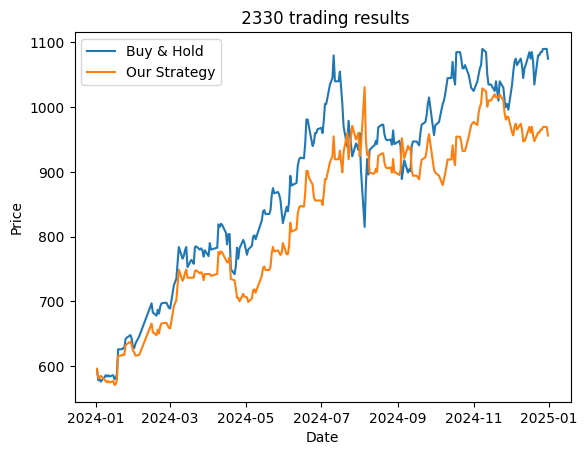

2317 鴻海 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.4,0.300000,-0.001360,-0.004055,15,3,7,3,2
test,0.5,0.666667,0.112323,0.149763,4,2,1,0,1


2317 鴻海 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.461538,0.375,0.029031,0.046539,13,3,5,3,2
test,0.750000,0.750,0.089296,0.089296,4,3,1,0,0


KeyboardInterrupt: 

In [5]:
from usable_movement import UsableMovment
from api import eval_mov

avgs = pd.DataFrame()
def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "MOV" : "EMA5"
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableMovment(env, i)
            eval_module.generate_factors()
            eval_module.expand_factors(llm_factors=llm)
            train_datarange, test_datarange = eval_module.split_exp()

            df = eval_module.run_taining(1, train_datarange, test_datarange, eval_mov)
            display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(1)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        plt.title(f" {env['stock_id']} trading results")
        plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        plt.plot(dplot, list_stag_balance, label="Our Strategy")  # orange

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()
            
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
    df_selected = df_stock_results.loc[:, selected_columns]

    columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
    averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()
    average_row = pd.DataFrame(averages).T
    average_row.index = ['平均值' + str(i)]
    average_row['winrate'] = round(wincount / ttl_count, 2)
    
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

    # display(df_selected_with_avg)
    return avgs

for i in range(1, 11):
    print(i)
    avgs = runAll(i, avgs)

# display(avgs)
# 計算最後一列的平均值
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['最終平均值']

# 將最終平均值添加到 avgs
avgs = pd.concat([avgs, final_average_row])

display(avgs)